In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

from neurodiffeq import diff
from neurodiffeq.conditions import IVP, DirichletBVP,NoCondition
from neurodiffeq.networks import FCNN, SinActv
from neurodiffeq.solvers import BaseSolver,BaseSolution
from neurodiffeq.monitors import Monitor1D
from neurodiffeq.generators import Generator1D,BaseGenerator
from neurodiffeq_conditions.conditions import ComposedCondition, ConditionComponent
from scipy.stats import qmc,truncnorm

from lnn import *

class BundleSolution4D(BaseSolution):
    def _compute_u(self, net, condition, xs1,xs2,xs3, ys1, *ts):
        return condition.enforce(net, xs1,xs2,xs3, ys1, *ts)

class BundleIntSolver4D(BaseSolver):

    def __init__(self, pde_system, conditions, xy_min, xy_max,
                 theta_min=None, theta_max=None, eq_param_index=(),
                 nets=None, train_generator=None, valid_generator=None, analytic_solutions=None, optimizer=None,
                 loss_fn=None, n_batches_train=1, n_batches_valid=4, metrics=None, n_output_units=1,
                 # deprecated arguments are listed below
                 batch_size=None, shuffle=None):

        if train_generator is None or valid_generator is None:
            if xy_min is None or xy_max is None:
                raise ValueError(f"Either generator is not provided, xy_min and xy_max should be both provided: \n"
                                 f"got xy_min={xy_min}, xy_max={xy_max}, "
                                 f"train_generator={train_generator}, valid_generator={valid_generator}")

        if isinstance(theta_min, (float, int)):
            theta_min = (theta_min,)
        elif theta_min is None:
            theta_min = ()

        if isinstance(theta_max, (float, int)):
            theta_max = (theta_max,)
        elif theta_max is None:
            theta_max = ()
        if len(theta_min) != len(theta_max):
            raise ValueError(
                f"length of theta_min and theta_max must be equal, " f"got {len(theta_min)} != {len(theta_max)}"
            )

        r_min = tuple(xy_min) + tuple(theta_min)
        r_max = tuple(xy_max) + tuple(theta_max)
        # print(r_min)
        n_input_units = len(r_min)
        a_minn,a_maxx = [],[]

        self.a_min, self.a_max = torch.tensor(a_minn),torch.tensor(a_maxx)

        self.r_min, self.r_max = r_min, r_max
        N_FUNCTIONS = len(conditions)
        N_COORDS = 4

        # Note: It is intentionally design in this way where `eq_param_index` and `self.eq_param_index`
        # both contain values offset by `N_FUNCTIONS + N_COORDS`. The first one (not bound to `self`) is used for the
        # `eq_param_filter` closure, while the second one (bound to `self`) is used for `_get_internal_variables()`.
        eq_param_index = tuple(N_FUNCTIONS + N_COORDS + idx for idx in eq_param_index)
        self.eq_param_index = eq_param_index

        # TODO: check and warn if there are variables neither used by conditions nor by equations

        def _diff_eqs_wrapper(*variables):
            funcs_and_coords = variables[:N_FUNCTIONS + N_COORDS]
            eq_params = tuple(variables[idx] for idx in eq_param_index)
            return pde_system(*funcs_and_coords, *eq_params)

        super(BundleIntSolver4D, self).__init__(
            diff_eqs=_diff_eqs_wrapper,
            conditions=conditions,
            nets=nets,
            train_generator=train_generator,
            valid_generator=valid_generator,
            analytic_solutions=analytic_solutions,
            optimizer=optimizer,
            loss_fn=loss_fn,
            n_batches_train=n_batches_train,
            n_batches_valid=n_batches_valid,
            metrics=metrics,
            n_input_units=n_input_units,
            n_output_units=n_output_units,
            shuffle=shuffle,
            batch_size=batch_size,
        )
    def additional_loss(self,residual,funcs,coords):

        u=self.get_solution(best=False,copy=False) 
        x1,x2,x3,y1=coords[0],coords[1],coords[2],coords[3]          

        in_val_x1 = torch.full((x1.size()[0],),self.r_min[0])  
        in_val_x2 = torch.full((x2.size()[0],),self.r_min[1])
        in_val_x3 = torch.full((x3.size()[0],),self.r_min[2])
        in_val_y1 = torch.full((y1.size()[0],),self.r_min[3])  

        a_min,a_max=self.a_min,self.a_max
        loss=0.
        size_pars,size_grid = len(self.r_min[4:]),x1.size()[0]
        rmin = self.r_min

        te_min,te_max = [param * torch.ones(size_grid) for param in self.r_min[4:]],[param * torch.ones(size_grid) for param in self.r_max[4:]]
        x2_term = u(x1,in_val_x2,x3,y1,*te_min)**2


        dux1 = diff(x2_term.view(-1,1),x1)**2
        d2ux2 = diff(dux1.view(-1,1),x2)**2
        d3ux3 = diff(d2ux2.view(-1,1),x3)**2
        loss+= torch.mean(dux1 + d2ux2 + d3ux3)

        return loss

    def get_solution(self, copy=True, best=True):

        nets = self.best_nets if best else self.nets
        conditions = self.conditions
        if copy:
            nets = deepcopy(nets)
            conditions = deepcopy(conditions)

        return BundleSolution4D(nets, conditions)

    def _get_internal_variables(self):
        available_variables = super(BundleIntSolver2D, self)._get_internal_variables()
        available_variables.update({
            'r_min': self.r_min,
            'r_max': self.r_max,
            'eq_param_index': self.eq_param_index,
        })
        return available_variables

class LatinHypercubeGeneratorNDbisp(BaseGenerator):

    def __init__(self, Nsamp = 2048, Ndim=2, r_min=(0.0, 0.0), r_max=(1.0, 1.0),target_point=(0.5,0.5),target_point_std=(0.1,0.1),target_point_frac=0.):

        super(LatinHypercubeGeneratorNDbisp, self).__init__()
        self.size = Nsamp
        self.r_min = r_min
        self.r_max = r_max
#         self.size = Nsamp
        r = []
        sampler = qmc.LatinHypercube(d=Ndim)
        if target_point_frac>1.: 
            raise ValueError("Fraction of target point cannot be higher than 1.")
            
        self.getter = lambda: tuple(torch.cat((torch.tensor(r_min[i]+sampler.random(n=round(Nsamp*(1.-target_point_frac)))[:,i]*(r_max[i]-r_min[i]),requires_grad=True),
                                              torch.tensor(truncnorm.rvs(a=(r_min[i]-target_point[i])/target_point_std[i], b=(r_max[i]-target_point[i])/target_point_std[i],
                                                            loc=target_point[i], scale=target_point_std[i], size=round(Nsamp*target_point_frac)),requires_grad=True) )) for i in range(Ndim))
                                               
#                                                torch.randn(round(Nsamp*target_point_frac))*target_point_std[i]+target_point[i])) for i in range(Ndim))        
    def get_examples(self):
        return self.getter()

    def _internal_vars(self) -> dict:
        d = super(LatinHypercubeGeneratorNDbisp, self)._internal_vars()
        d.update(dict(
            Ndim=self.Ndim,
            Nsamp=self.Nsamp,
            r_max=self.r_max,
            r_min=self.r_min,
        ))
        return d




order = 4

inmin,inmax=0.,1.
x1min,x2min,x3min,y1min,y2min,y3min=inmin,inmin,inmin,inmin,inmin,inmin
x1max,x2max,x3max,y1max,y2max,y3max=inmax,inmax,inmax,inmax,inmax,inmax
nets = [
    CustomNN(n_input_units=order, n_output_units=1, hidden_units=[32, 16, 16, 8, 8], first= False)
]

# nets = [
#     CustomNN(n_input_units=1, n_output_units=1, hidden_units=[16,16])
# ]

# nets = [CustomNN(n_input_units=4, n_output_units=1, hidden_units=[32,32], actv=SineActivation,
#                                  sigma_learnable=True, initial_sigma=0.06)]

# Define a Dirichlet condition function that returns zero
def zero_condition(*coords):
    return 0

# Create condition components for each coordinate
components = []
for i in range(order):  # Assuming "order" coordinates
    component = ConditionComponent(w=-1e-6*i, f_dirichlet=zero_condition, coord_index=i)
    components.append(component)

# Combine components into a composed condition
composed_condition = ComposedCondition(components=components)


if order==4:
    mins = (x1min,x2min,x3min,y1min)
    maxs = (x1max,x2max,x3max,y1max)
    target_point = (0.8,0.8,0.8,0.8)
    target_point_std = (0.01,0.01,0.01,0.01)
    equation = lambda u,kpa,kpb,kpc,kppa: [
    diff(diff(diff(diff(u,kpa),kpb),kpc),kppa) - 10. 
    ]
    equation_an = lambda kpa,kpb,kpc,kppa: 10.*kpa*kpb*kpc*kppa 
    genhyp = LatinHypercubeGeneratorNDbisp(Nsamp=4096,Ndim = order, r_min=mins, r_max= maxs,
                                                 target_point=target_point,target_point_std=target_point_std,target_point_frac=0.3
                                                )
    solver = BundleIntSolver4D(
        pde_system=equation,
    #    conditions=[NoCondition()],
        conditions =[composed_condition],
        xy_min=(x1min,x2min,x3min,y1min),
        xy_max=(x1max,x2max,x3max,y1max),
        nets=nets,
        train_generator=genhyp,
        valid_generator=genhyp,
    #    theta_min=mins_theta,theta_max=maxs_theta,eq_param_index=(0,1,2,3,4,5)
    )

In [2]:
solver.fit(max_epochs=150000)

Training Progress:   0%|                             | 0/150000 [00:00<?, ?it/s]

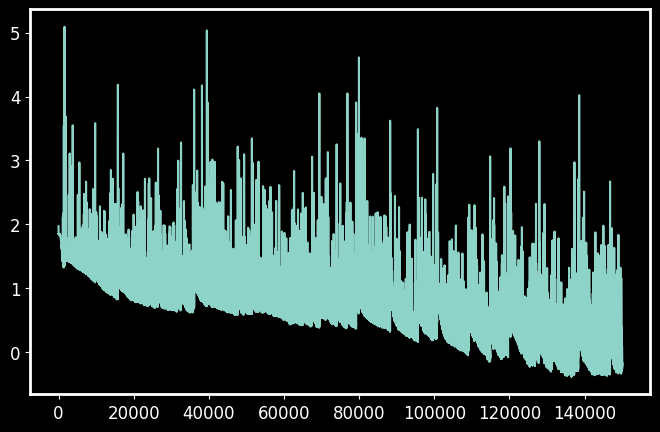

In [3]:
plt.plot(np.log10(solver.metrics_history['train_loss']))
plt.show()

In [4]:
min(solver.metrics_history['train_loss'])

0.4110166847315723